# Vehicle Insurance Prediction

## Objective

The objective of this project is to build a machine learning model that predicts whether a customer will be interested in purchasing vehicle insurance based on demographic and vehicle-related information.

The workflow includes:

- Data preprocessing
- Feature engineering
- Handling class imbalance
- Model comparison
- Hyperparameter tuning
- Final model selection and evaluation

## Importing Data and required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [4]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [7]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [8]:
df.nunique()

id                      381109
Gender                       2
Age                         66
Driving_License              2
Region_Code                 53
Previously_Insured           2
Vehicle_Age                  3
Vehicle_Damage               2
Annual_Premium           48838
Policy_Sales_Channel       155
Vintage                    290
Response                     2
dtype: int64

# Key observations:
   - shape: 381109x12
   - No null or duplicated values 
   - 3 categorical columns 
   - Response is our target feature

## EDA

In [9]:
df = df.drop("id", axis =1)

In [10]:
df.sample()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
186548,Female,62,1,8.0,0,1-2 Year,Yes,32827.0,25.0,85,0


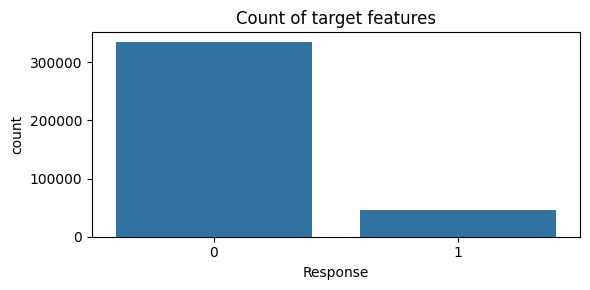

In [40]:
plt.figure(figsize=(6,3))
sns.countplot(data =df , x = "Response")
plt.title("Count of target features")
plt.xlabel("Response")
plt.ylabel("count")

plt.tight_layout()
plt.show()

### Key observations:
- The target variable is highly imbalanced, with Response=0 dominating the dataset compared to Response=1. 

In [12]:
num_cols = df.select_dtypes(include = "number").columns
cat_cols = df.select_dtypes(include = "object").columns

In [13]:
print(f"Numerical features: {num_cols} \nCatagotical features: {cat_cols}")

Numerical features: Index(['Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object') 
Catagotical features: Index(['Gender', 'Vehicle_Age', 'Vehicle_Damage'], dtype='object')


## Categorical features analysis

In [14]:
cat_cols 

Index(['Gender', 'Vehicle_Age', 'Vehicle_Damage'], dtype='object')

In [15]:
df[cat_cols].nunique().sum

<bound method Series.sum of Gender            2
Vehicle_Age       3
Vehicle_Damage    2
dtype: int64>

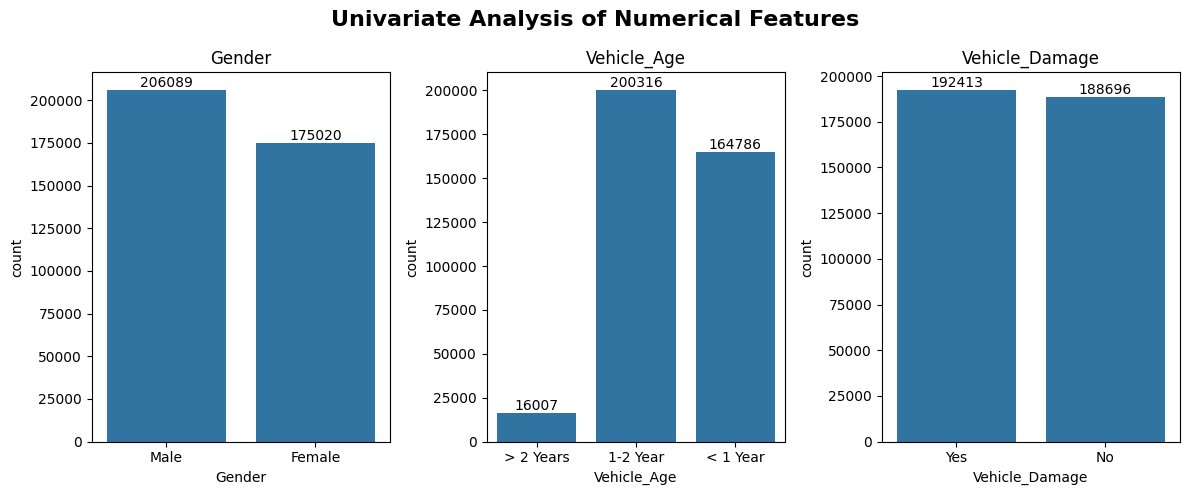

In [16]:
cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

fig, axes = plt.subplots(1,3, figsize= (12,5))
plt.suptitle("Univariate Analysis of Numerical Features", fontsize = 16, fontweight = 'bold')
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(data=df, x = col, ax = axes[i])
    ax.bar_label(ax.containers[0])
    ax.set_title(col)
plt.tight_layout()
plt.show()

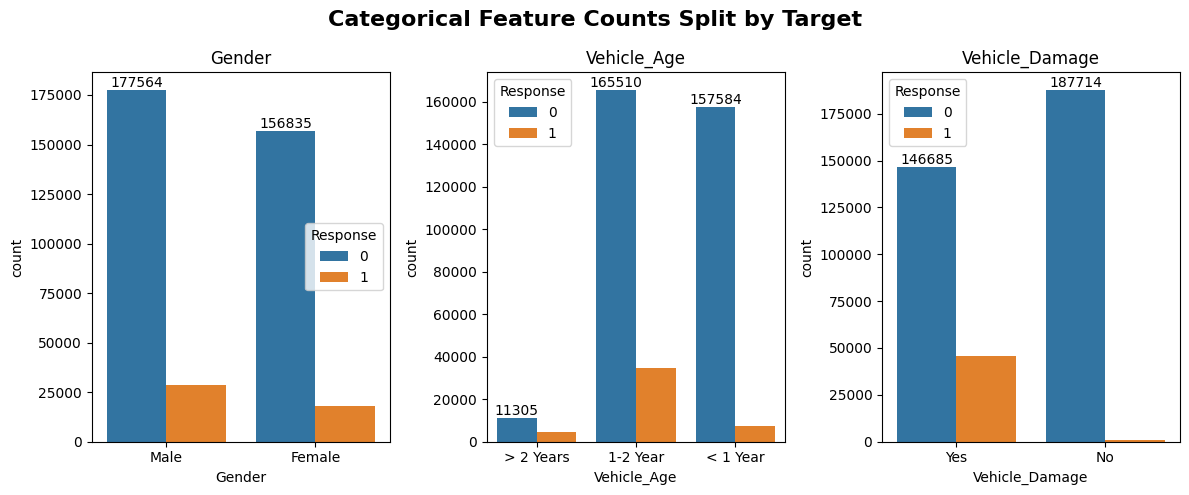

In [17]:
# Categorical features and response

cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

fig, axes = plt.subplots(1,3, figsize= (12,5))
plt.suptitle("Categorical Feature Counts Split by Target", fontsize = 16, fontweight = 'bold')
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(data=df, x = col, hue = 'Response' ,ax = axes[i])
    ax.bar_label(ax.containers[0])
    ax.set_title(col)
plt.tight_layout()
plt.show()



### Key observation:
- Clients with older and damaged cars tend to have a higher probability of purchasing insurance.
- Gender does not show a significant impact on insurance response probability.
   

## Numerical features analysis

In [18]:
num_cols

Index(['Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

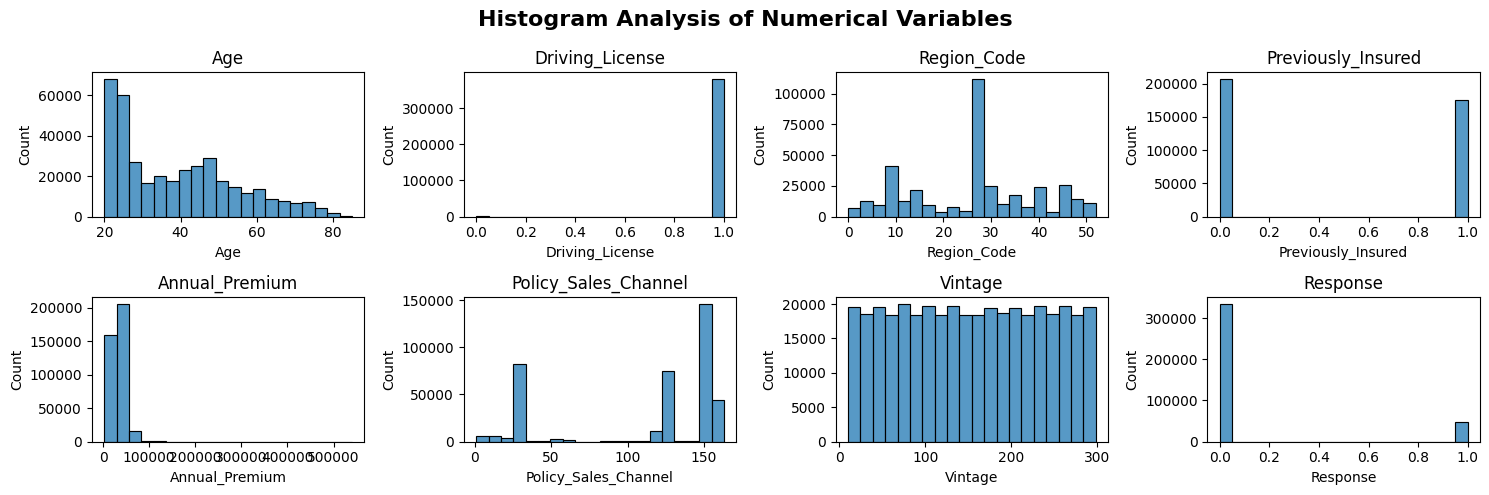

In [19]:
cols = ['Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response']

fig, axes = plt.subplots(2,4, figsize= (15,5))
plt.suptitle("Histogram Analysis of Numerical Variables", fontsize = 16, fontweight = 'bold')
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.histplot(data=df, x = col, bins= 20, ax = axes[i])
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Relation of Driving license and Previously Insured with Response

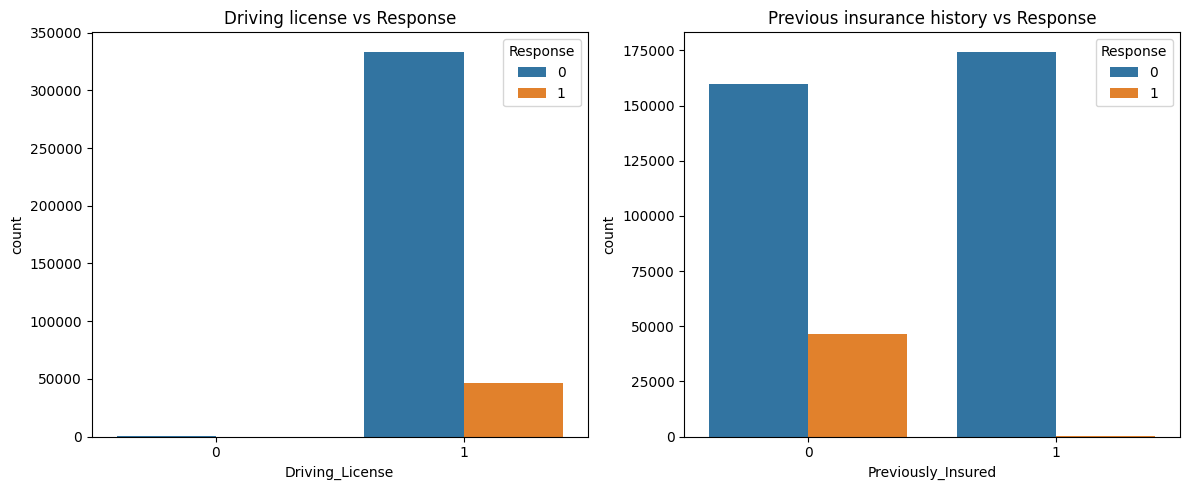

In [27]:
fig , axes= plt.subplots(1,2, figsize = (12,5))
axes = axes.flatten()
sns.countplot(ax = axes[0], data = df, x = df["Driving_License"], hue = df["Response"])
axes[0].set_title("Driving license vs Response") 

sns.countplot(ax = axes[1], data = df, x = df["Previously_Insured"], hue = df["Response"])
axes[1].set_title("Previous insurance history vs Response")

plt.tight_layout()
plt.show()

### Key observation:
- Driving license status does not significantly influence insurance response, as most clients already possess a license
- Clients without prior insurance history show a comparatively higher probability of purchasing insurance.

# Distributions, skewness and outliers

In [29]:
df.columns

Index(['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

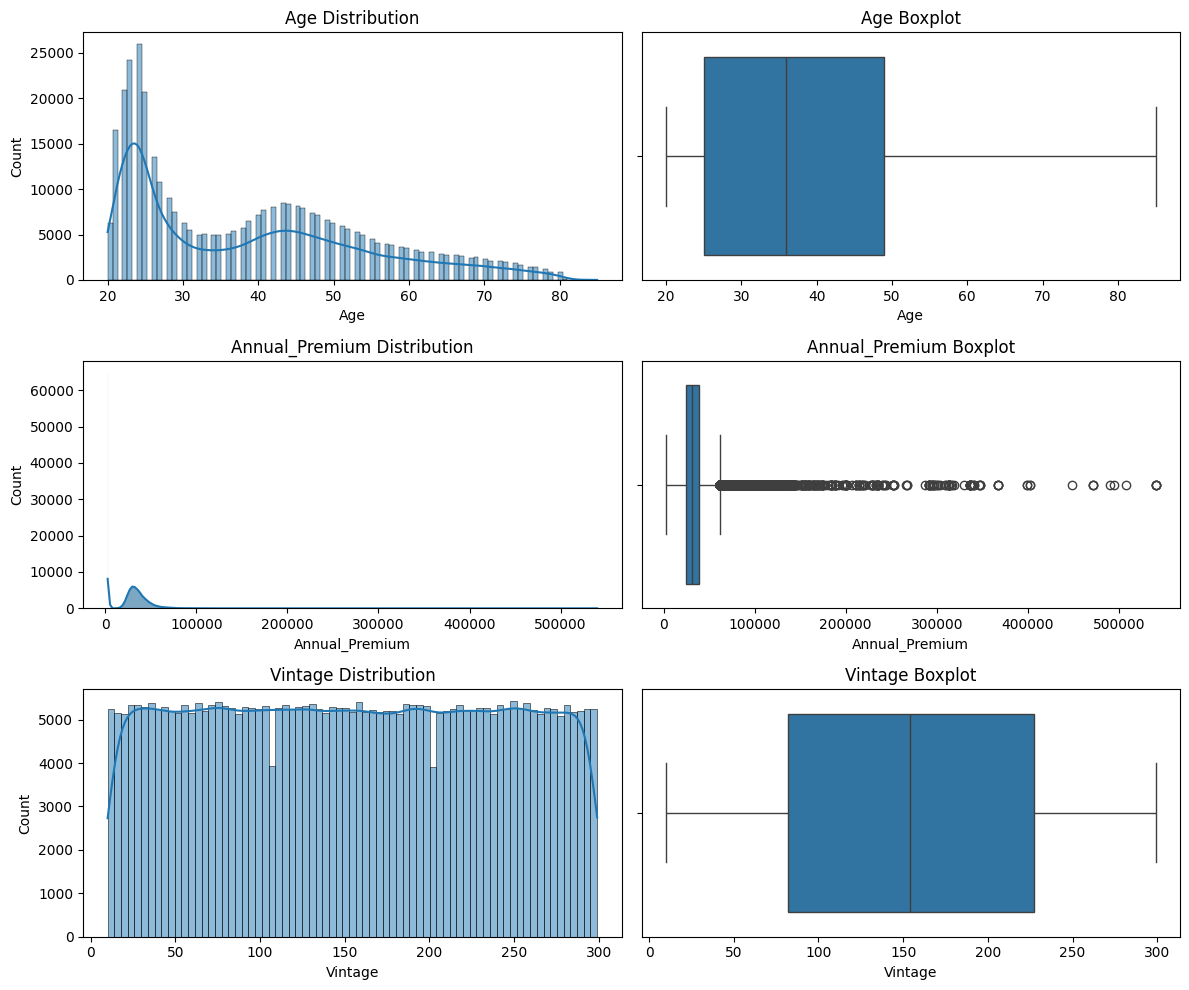

In [35]:
continious_cols = ["Age", "Annual_Premium", "Vintage"]

fig, axes = plt.subplots(len(continious_cols),2, figsize = (12,10))

for i, col in enumerate(continious_cols):
    sns.histplot(df[col], kde = True, ax=axes[i,0])
    axes[i,0].set_title(f"{col} Distribution")

    sns.boxplot(x= df[col], ax=axes[i,1])
    axes[i,1].set_title(f"{col} Boxplot")   

plt.tight_layout()

In [38]:
for col in ["Age", "Annual_Premium", "Vintage"]:
    print(f"{col}: {df[col].skew():.2f}")

Age: 0.67
Annual_Premium: 1.77
Vintage: 0.00


### Age
- Majority of customers are between 20–30 years old.
- A second concentration appears around 40–50 years, indicating a slightly bimodal distribution.
- No outliers are detected using the IQR rule.

### Annual_Premium
- The feature is highly positively skewed.
- Most customers pay relatively low premiums, while a small number pay substantially higher premiums.
- Numerous statistical outliers are observed. These are retained because they likely represent valid premium amounts.

### Vintage
- The feature is approximately uniformly distributed across its range.
- No significant skewness or outliers are observed.